In [1]:
import numpy as np

In [6]:
left=-(105/(105+36))*np.log2(105/(105+36))-(36/(105+36))*np.log2(36/(105+36))
left

0.8196004346196011

In [7]:
right=-(34/(34+122))*np.log2(34/(34+122))-(122/(34+122))*np.log2(122/(34+122))
right

0.7564041945982505

In [8]:
((105+36)/(105+36+34+122))*left+((34+122)/(105+36+34+122))*right

0.786406449961922

In [10]:
import numpy as np
import matplotlib.pyplot as plt
x=[i/100 for i in range(1,101)]
y=[-np.log2(i) for i in x]

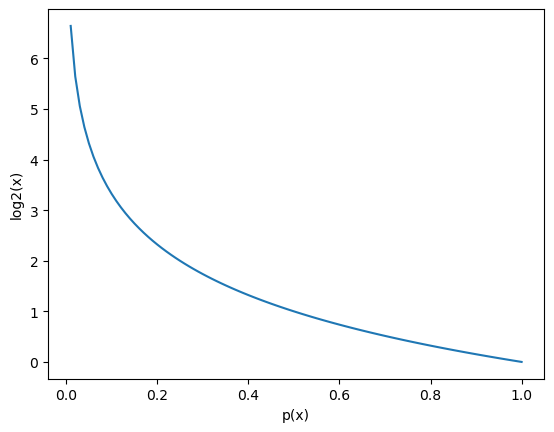

In [12]:
plt.xlabel("p(x)")
plt.ylabel("log2(x)")
plt.plot(x,y)

In [13]:
import pandas as pd

In [38]:
data=[
    [1,0,0,'打球'],
    [1,0,1,'打球'],
    [0,1,1,'打球'],
    [0,0,1,'不打球'],
    [1,1,1,'打球']
] #也可是a,b
df=pd.DataFrame(data)
data_length=len(data) #length行数

In [39]:
df

,0,1,2,3
0,1,0,0,打球
1,1,0,1,打球
2,0,1,1,打球
3,0,0,1,不打球
4,1,1,1,打球


In [31]:
target=df.iloc[:,-1] #取了所有行 最后一列，即“打球”“不打球”
label_counts=target.value_counts()
label_counts

3
打球     4
不打球    1
Name: count, dtype: int64

In [32]:
label_dict=label_counts.to_dict()
label_dict

{'打球': 4, '不打球': 1}

In [33]:
entropy=0

In [23]:
for key in label_diet:
    prob=float(label_dict[key])/data_length 
    entropy=entropy-prob*np.log2(prob)

In [24]:
entropy #计算信息熵

0.7219280948873623

分割数据

In [34]:
groups=df.groupby(by=0)
groups.groups.keys()

dict_keys(['a', 'b'])

In [37]:
df.loc[groups.groups[0],:] #0是值

,0,1,2,3
0,a,b,b,打球
1,a,b,a,打球
4,a,a,a,打球


In [28]:
df.loc[groups.groups[1],:] #1是值

,0,1,2,3
0,1,0,0,打球
1,1,0,1,打球
4,1,1,1,打球


封装函数

In [40]:
def ent(data):
    df=pd.DataFrame(data)
    data_length=len(data)
    target=df.iloc[:,-1]
    label_counts=target.value_counts()
    label_dict=label_counts.to_dict()
    entropy=0
    for key in label_diet:
        prob=float(label_dict[key])/data_length 
        entropy=entropy-prob*np.log2(prob)
    return entropy

In [41]:
ent(data)

0.7219280948873623

In [47]:
def split(data,feature_rank):
    df=pd.DataFrame(data)
    groups=df.groupby(by=feature_rank)
    data_group={}
    for key in groups.groups.keys():
        data_group[key]=df.loc[groups.groups[key],:] 
    return data_group

In [48]:
data_group=split(data,feature_rank=1)

In [49]:
data_group

{0:    0  1  2    3
 0  1  0  0   打球
 1  1  0  1   打球
 3  0  0  1  不打球,
 1:    0  1  2   3
 2  0  1  1  打球
 4  1  1  1  打球}

In [50]:
init_ent=ent(data)

In [51]:
new_ent=0

In [54]:
for key in data_group:
     prob=len(data_group[key])/len(data)
     new_ent=new_ent+prob*ent(data_group[key])

KeyError: '不打球'

In [56]:
gain=init_ent-new_ent
print(init_ent)
print(gain)

0.7219280948873623
0.17095059445466865
